In [1]:
import os
import fnmatch
import pandas as pd
import json
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:

#########################################
### Data Preprocessing (Local setup)
#######################################

# path_list = []
# for root, dirs, files in os.walk('./'):
#     # print(root)
#     if len(root)>2:
#         path_list.append(root)

# print(path_list)


['./.git', './.git/objects', './.git/objects/3e', './.git/objects/pack', './.git/objects/info', './.git/objects/de', './.git/objects/f9', './.git/objects/82', './.git/info', './.git/logs', './.git/logs/refs', './.git/logs/refs/heads', './.git/logs/refs/remotes', './.git/logs/refs/remotes/origin', './.git/hooks', './.git/refs', './.git/refs/heads', './.git/refs/tags', './.git/refs/remotes', './.git/refs/remotes/origin']


In [7]:
dir_path = '/Users/khangdao/Desktop/Project DS/Random_series'

# List all folders in the directory
path_list = [f.path for f in os.scandir(dir_path) if f.is_dir()]

# Print the list of folders
# print(path_list)

images = []
for path in path_list:
    # path = './Random_series_001'
    data = pd.read_csv(f'{path}/image_data.csv')
    df = pd.DataFrame(data)
    boundary = pd.DataFrame()
    df = df.drop(['BaS', 'Sn2BaS3', 'SnS', 'BaS_thickness_cm', 'Sn2BaS3_thickness_cm', 'SnS_thickness_cm'], axis=1)

    # Find the .tif file named Filtered_R_Image in the same directory
    for file in os.listdir(path):
        if file == "Filtered_R_Image.tif":
            # Open the .tif file
            image = Image.open(os.path.join(path, file))
            # Append the image to the images list
            images.append(image)

    with open(f'{path}/settings.json', 'r') as f:
        settings = json.load(f)
    
    boundary1 = settings['boundaries'][1]
    boundary2 = settings['boundaries'][2]
    if 'boundaries' in settings and len(settings['boundaries']) > 2:
        boundary = pd.DataFrame({
        'boundary1': [boundary1],
        'boundary2': [boundary2]
    })
    else:
        raise ValueError("Settings do not contain valid boundaries.")
    df['target'] = df['F'].apply(lambda x: 1 if x < boundary1 else 2 if boundary1 <= x <= boundary2 else 3)

    boundary.to_csv(f'{path}/boundary.csv', index=False)
    df.to_csv(f'{path}/image_data_1.csv', index=False)

print(df.head())
print(settings['boundaries'])

##########################################
# TRAIN - VAL - TEST (Local setup)
##########################################

# path_list = []
# for root, dirs, files in os.walk('./'):
#     # print(root)
#     if len(root)>2:
#         path_list.append(root)

train_directories = path_list[:100]
val_directories = path_list[100:150]
test_directories = path_list[150:]

print(train_directories)
print(val_directories)
print(test_directories)

      x     y            Sn            Ba         F  target
0 -2.49 -0.49  4.323034e-07  2.444360e-07  0.638803       1
1 -2.49 -0.44  4.309572e-07  2.435826e-07  0.638891       1
2 -2.49 -0.39  4.296010e-07  2.427209e-07  0.638981       1
3 -2.49 -0.34  4.282348e-07  2.418509e-07  0.639075       1
4 -2.49 -0.29  4.268590e-07  2.409730e-07  0.639171       1
[0, 0.64, 0.76, 1]
['/Users/khangdao/Desktop/Project DS/Random_series/Random_series_041', '/Users/khangdao/Desktop/Project DS/Random_series/Random_series_079', '/Users/khangdao/Desktop/Project DS/Random_series/Random_series_046', '/Users/khangdao/Desktop/Project DS/Random_series/Random_series_070', '/Users/khangdao/Desktop/Project DS/Random_series/Random_series_084', '/Users/khangdao/Desktop/Project DS/Random_series/Random_series_048', '/Users/khangdao/Desktop/Project DS/Random_series/Random_series_083', '/Users/khangdao/Desktop/Project DS/Random_series/Random_series_077', '/Users/khangdao/Desktop/Project DS/Random_series/Random_ser

In [9]:
def combine_data_and_images(directories, data_type):
    combined_data = pd.DataFrame()
    df_list = []
    images = []  # Initialize an empty list to store the images
    boundary_list = []

    for directory in directories:
        # Construct paths for CSV and image files
        file_path = os.path.join(directory, 'image_data_1.csv')
        image_path = os.path.join(directory, 'Filtered_R_Image.tif')
        boundary_path = os.path.join(directory, 'boundary.csv')

        # Check if the CSV file exists
        if os.path.exists(file_path):
            df = pd.read_csv(file_path)
            df_list.append(df)
            combined_data = pd.concat([combined_data, df], ignore_index=True)
        else:
            print(f"File not found: {file_path}")

        # Check if the image file exists
        if os.path.exists(image_path):
            img = Image.open(image_path)
            images.append(img)
        else:
            print(f"Image not found: {image_path}")

        # Check if the boundary CSV file exists
        if os.path.exists(boundary_path):
            boundary = pd.read_csv(boundary_path)
            boundary_list.append(boundary.values.flatten())
        else:
            print(f"File not found: {boundary_path}")

    # Save the combined DataFrame to a CSV file
    output_csv = f'{data_type}_data.csv'
    combined_data.to_csv(output_csv, index=False)
    print(f"Data combined successfully into '{output_csv}'.")

    return images, df_list, boundary_list

train_images_list, train_df_list, train_boundary_list = combine_data_and_images(train_directories, 'train')
val_images_list, val_df_list, val_boundary_list = combine_data_and_images(val_directories, 'val')
test_images_list, test_df_list, test_boundary_list = combine_data_and_images(test_directories, 'test')

Data combined successfully into 'train_data.csv'.
Data combined successfully into 'val_data.csv'.
Data combined successfully into 'test_data.csv'.


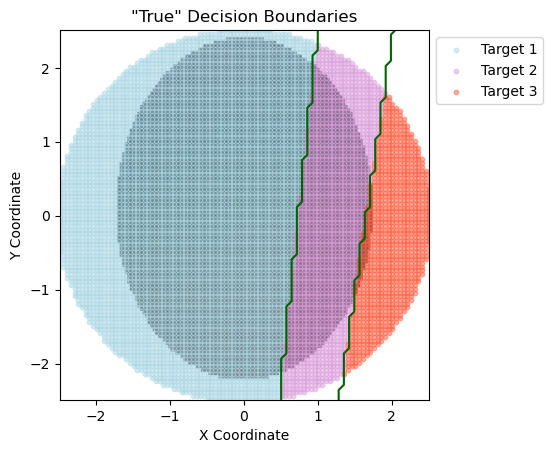

In [19]:
def plot_targets_on_image(df, img):

    img_width, img_height = img.size

    # Create a figure and axis
    fig, ax = plt.subplots()

    # Display the image
    ax.imshow(img, extent=[df['x'].min(), df['x'].max(), df['y'].min(), df['y'].max()])
    ax.imshow(img, extent=[0, img_width, 0, img_height], aspect='auto')

    # Plot points based on target values
    colors = {1: 'lightblue', 2: 'plum', 3: 'tomato'}
    
    # Plot each unique coordinate for each target
    for target in colors.keys():
        target_points = df[df['target'] == target]
        
        # Use the coordinates to plot the points on the image
        ax.scatter(target_points['x'], target_points['y'], 
                   color=colors[target], 
                   label=f'Target {target}', 
                   s=10,
                   alpha = 0.5)

    # Set the axis limits to match the coordinate range
    ax.set_xlim([df['x'].min(), df['x'].max()])
    ax.set_ylim([df['y'].min(), df['y'].max()])

    # Encode the target labels
    le = LabelEncoder()
    df['target_encoded'] = le.fit_transform(df['target'])

    # Fit logistic regression model
    X = df[['x', 'y']]
    y = df['target_encoded']
    model = LogisticRegression(multi_class='multinomial')
    model.fit(X, y)
    
    # Create a mesh to plot the decision boundaries
    x_min, x_max = df['x'].min() - 1, df['x'].max() + 1
    y_min, y_max = df['y'].min() - 1, df['y'].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    # Ensure xx and yy are DataFrames with the appropriate column names
    grid_points = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=['x', 'y'])
    Z = model.predict(grid_points)
    Z = Z.reshape(xx.shape)

    # Plot decision boundaries
    ax.contour(xx, yy, Z, levels=[0.5, 1.5], colors=['darkgreen', 'darkgreen'], linestyles=['-', '-'])

    # Add labels and legend
    ax.set_title('"True" Decision Boundaries')
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    
    # Show the plot
    plt.show()

plot_targets_on_image(train_df_list[9], train_images_list[9]) 

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from PIL import Image

def plot_targets_on_image(df):
    # Determine the range of coordinates
    x_min, x_max = df['x'].min(), df['x'].max()
    y_min, y_max = df['y'].min(), df['y'].max()
    # print(x_min, x_max, y_min, y_max)
    
    # Create a blank white image based on the coordinate range
    img_width = int(x_max - x_min)
    img_height = int(y_max - y_min)
    img = Image.new('RGB', (img_width, img_height), 'white')
    print(img_width, img_height)
    # Create a figure and axis
    fig, ax = plt.subplots()

    # Display the blank image
    ax.imshow(img, extent=[x_min, x_max, y_min, y_max], aspect='equal')

    # Plot points based on target values
    colors = {1: 'lightblue', 2: 'plum', 3: 'tomato'}
    
    # Plot each unique coordinate for each target
    for target in colors.keys():
        target_points = df[df['target'] == target]
        
        # Use the coordinates to plot the points on the image
        ax.scatter(target_points['x'], target_points['y'], 
                   color=colors[target], 
                   label=f'Target {target}', 
                   s=10,
                   alpha=0.5)

    # Set the axis limits to match the coordinate range
    ax.set_xlim([x_min, x_max])
    ax.set_ylim([y_min, y_max])

    # Encode the target labels
    le = LabelEncoder()
    df['target_encoded'] = le.fit_transform(df['target'])

    # Fit logistic regression model
    X = df[['x', 'y']]
    y = df['target_encoded']
    model = LogisticRegression(multi_class='multinomial')
    model.fit(X, y)
    
    # Create a mesh to plot the decision boundaries
    xx, yy = np.meshgrid(np.linspace(x_min - 1, x_max + 1, 100), np.linspace(y_min - 1, y_max + 1, 100))
    
    # Ensure xx and yy are DataFrames with the appropriate column names
    grid_points = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=['x', 'y'])
    Z = model.predict(grid_points)
    Z = Z.reshape(xx.shape)

    # Plot decision boundaries
    ax.contour(xx, yy, Z, levels=[0.5, 1.5], colors=['darkgreen', 'darkgreen'], linestyles=['-', '-'])

    # Add labels and legend
    ax.set_title('"True" Decision Boundaries')
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    
    # Show the plot
    plt.show()

4 4


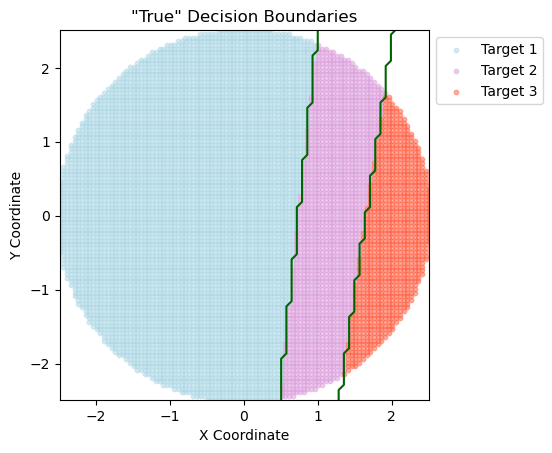

In [29]:
plot_targets_on_image(train_df_list[9])

In [22]:
A =  train_images_list[9]
A
B = np.array(A)
B

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

In [8]:

train_data = pd.read_csv('train_data.csv')
val_data = pd.read_csv('val_data.csv')
test_data = pd.read_csv('test_data.csv')



# Split the data frames into the desired number of sub-data frames
train_splits = np.array_split(train_data, 100)

val_splits = np.array_split(val_data, 50)

test_splits = np.array_split(test_data, 50)


train_data.head()


,x,y,Sn,Ba,F,target
0,-2.49,-0.49,3.062847e-07,2.233571e-07,0.578287,2
1,-2.49,-0.44,3.053393e-07,2.225576e-07,0.578407,2
2,-2.49,-0.39,3.043868e-07,2.217501e-07,0.578532,2
3,-2.49,-0.34,3.034276e-07,2.209347e-07,0.578660,2
4,-2.49,-0.29,3.024617e-07,2.201116e-07,0.578793,2


In [9]:
# Assuming features_train_splits is already defined and contains 100 DataFrames
train_df = pd.DataFrame()
val_df = pd.DataFrame()
test_df = pd.DataFrame()

for d in range(100):
    # Sort the DataFrame by 'x' and 'y'
    df = train_splits[d].sort_values(by=['x', 'y'])
    
    # Create the 'i' column
    # df['i'] = range(8092)
    df['i'] = range(len(df))
        
    # Create the 'photo_index' column
    df['photo_index'] = d
    
    # Append the processed DataFrame to the concatenated DataFrame
    train_df = pd.concat([train_df, df], axis=0)

for d in range(50):
    # Sort the DataFrame by 'x' and 'y'
    df_val = val_splits[d].sort_values(by=['x', 'y'])
    df_test = test_splits[d].sort_values(by=['x', 'y'])
    
    # Create the 'i' column
    df_val['i'] = range(len(df_val))
    df_test['i'] = range(len(df_test))
        
    # Create the 'photo_index' column
    df_val['photo_index'] = d+100
    df_test['photo_index'] = d+150
    
    # Append the processed DataFrame to the concatenated DataFrame
    val_df = pd.concat([val_df, df_val], axis=0)
    test_df = pd.concat([test_df, df_test], axis=0)


In [10]:
import pandas as pd

train_df = pd.DataFrame()
val_df = pd.DataFrame()
test_df = pd.DataFrame()

# Assuming train_splits, val_splits, and test_splits are already defined

for d in range(100):
    # Sort the DataFrame by 'x' and 'y'
    df = train_splits[d].sort_values(by=['x', 'y'])
    
    # Create the 'i' and 'j' columns
    df['i'] = df['x'].rank(method='dense').astype(int) - 1  # Unique integer for each unique x
    df['j'] = df['y'].rank(method='dense').astype(int) - 1  # Unique integer for each unique y
        
    # Create the 'photo_index' column
    df['photo_index'] = d
    
    # Append the processed DataFrame to the concatenated DataFrame
    train_df = pd.concat([train_df, df], axis=0)

for d in range(50):
    # Sort the DataFrame by 'x' and 'y'
    df_val = val_splits[d].sort_values(by=['x', 'y'])
    df_test = test_splits[d].sort_values(by=['x', 'y'])
    
    # Create the 'i' and 'j' columns
    df_val['i'] = df_val['x'].rank(method='dense').astype(int) - 1
    df_val['j'] = df_val['y'].rank(method='dense').astype(int) - 1
    df_test['i'] = df_test['x'].rank(method='dense').astype(int) - 1
    df_test['j'] = df_test['y'].rank(method='dense').astype(int) - 1
        
    # Create the 'photo_index' column
    df_val['photo_index'] = d + 100
    df_test['photo_index'] = d + 150
    
    # Append the processed DataFrame to the concatenated DataFrame
    val_df = pd.concat([val_df, df_val], axis=0)
    test_df = pd.concat([test_df, df_test], axis=0)

In [11]:
train_df.head()

,x,y,Sn,Ba,F,target,i,j,photo_index
0,-2.49,-0.49,3.062847e-07,2.233571e-07,0.578287,2,0,40,0
1,-2.49,-0.44,3.053393e-07,2.225576e-07,0.578407,2,0,41,0
2,-2.49,-0.39,3.043868e-07,2.217501e-07,0.578532,2,0,42,0
3,-2.49,-0.34,3.034276e-07,2.209347e-07,0.578660,2,0,43,0
4,-2.49,-0.29,3.024617e-07,2.201116e-07,0.578793,2,0,44,0


In [12]:
# data_train = train_df[[ 'Sn', 'Ba','F']]
# data_val = val_df[['Sn', 'Ba','F']]
# data_test = test_df[['Sn', 'Ba','F']]

data_train = train_df[[ 'x', 'y','Sn', 'Ba','F']]
data_val = val_df[['x', 'y','Sn', 'Ba','F']]
data_test = test_df[['x', 'y','Sn', 'Ba','F']]


label_train = train_df[['target']]
label_val = val_df[['target']]
label_test = test_df[['target']]


In [13]:
from sklearn.multioutput import MultiOutputClassifier
clf = MultiOutputClassifier(LogisticRegression())

data_train = train_df[[ 'x', 'y','Sn', 'Ba','F']]
data_val = val_df[['x', 'y','Sn', 'Ba','F']]
data_test = test_df[['x', 'y','Sn', 'Ba','F']]


label_train = train_df[['target']]
label_val = val_df[['target']]
label_test = test_df[['target']]

clf.fit(data_train, label_train)

val_pred = clf.predict(data_val)

val_accuracy = accuracy_score(label_val, val_pred)
print(f"Validation Accuracy: {val_accuracy}")

test_pred = clf.predict(data_test)

test_accuracy = accuracy_score(test_pred, label_test)
print(f"Test Accuracy: {test_accuracy}")

Validation Accuracy: 0.8196465645081562
Test Accuracy: 0.8301186356895699


In [14]:
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

clf = MultiOutputClassifier(LogisticRegression())

# Apply log transformation to 'Sn' and 'Ba'
train_df['log_Sn'] = np.log(train_df['Sn'])
train_df['log_Ba'] = np.log(train_df['Ba'])
val_df['log_Sn'] = np.log(val_df['Sn'])
val_df['log_Ba'] = np.log(val_df['Ba'])
test_df['log_Sn'] = np.log(test_df['Sn'])
test_df['log_Ba'] = np.log(test_df['Ba'])

data_train = train_df[['x', 'y', 'log_Sn', 'log_Ba', 'F']]
data_val = val_df[['x', 'y', 'log_Sn', 'log_Ba', 'F']]
data_test = test_df[['x', 'y', 'log_Sn', 'log_Ba', 'F']]

label_train = train_df[['target']]
label_val = val_df[['target']]
label_test = test_df[['target']]

clf.fit(data_train, label_train)

val_pred = clf.predict(data_val)

val_accuracy = accuracy_score(label_val, val_pred)
print(f"Validation Accuracy: {val_accuracy}")

test_pred = clf.predict(data_test)

test_accuracy = accuracy_score(test_pred, label_test)
print(f"Test Accuracy: {test_accuracy}")

Validation Accuracy: 0.8198344043499752
Test Accuracy: 0.8302867029164607


In [15]:
# Convert predictions to DataFrames
val_pred_df = pd.DataFrame(val_pred, columns=['target_pred'])
test_pred_df = pd.DataFrame(test_pred, columns=['target_pred'])

# Add predictions as new columns to the original DataFrames
data_val = pd.concat([val_df.reset_index(drop=True), val_pred_df], axis=1)
data_test = pd.concat([test_df.reset_index(drop=True), test_pred_df], axis=1)

# Check the results
print(data_val.head())
print(data_test.head())

# Create lists of data frames based on photo_index and sort them
val_list_pred = []
test_list_pred = []
for i in range(50):
    val_subset = data_val[data_val['photo_index'] == i + 100].sort_values(by='i').reset_index(drop=True)
    test_subset = data_test[data_test['photo_index'] == i + 150].sort_values(by='i').reset_index(drop=True)
    val_list_pred.append(val_subset)
    test_list_pred.append(test_subset)

val_list_pred[8]

      x     y            Sn            Ba         F  target  i   j  \
0 -2.49 -0.49  2.607105e-07  2.415551e-07  0.519069       1  0  40   
1 -2.49 -0.44  2.598774e-07  2.406691e-07  0.519187       1  0  41   
2 -2.49 -0.39  2.590378e-07  2.397741e-07  0.519310       1  0  42   
3 -2.49 -0.34  2.581917e-07  2.388702e-07  0.519436       1  0  43   
4 -2.49 -0.29  2.573394e-07  2.379576e-07  0.519566       1  0  44   

   photo_index     log_Sn     log_Ba  target_pred  
0          100 -15.159855 -15.236168            1  
1          100 -15.163056 -15.239843            1  
2          100 -15.166292 -15.243569            1  
3          100 -15.169563 -15.247346            1  
4          100 -15.172870 -15.251173            1  
      x     y            Sn            Ba         F  target  i   j  \
0 -2.49 -0.49  3.294041e-07  2.957413e-07  0.526924       1  0  40   
1 -2.49 -0.44  3.283515e-07  2.946957e-07  0.527009       1  0  41   
2 -2.49 -0.39  3.272907e-07  2.936398e-07  0.527097      

,x,y,Sn,Ba,F,target,i,j,photo_index,log_Sn,log_Ba,target_pred
0,-2.49,-0.49,5.027573e-07,3.162954e-07,0.613828,2,0,40,108,-14.503158,-14.966589,2
1,-2.49,0.46,4.690988e-07,2.918750e-07,0.616445,2,0,59,108,-14.572452,-15.046940,2
2,-2.49,0.41,4.709662e-07,2.932432e-07,0.616279,2,0,58,108,-14.568479,-15.042263,2
3,-2.49,0.36,4.728246e-07,2.946038e-07,0.616116,2,0,57,108,-14.564541,-15.037634,2
4,-2.49,0.26,4.765131e-07,2.973010e-07,0.615798,2,0,55,108,-14.556771,-15.028521,2
...,...,...,...,...,...,...,...,...,...,...,...,...
8087,2.51,-0.24,9.635715e-07,1.536452e-07,0.862475,3,100,45,108,-13.852619,-15.688620,3
8088,2.51,-0.34,9.737993e-07,1.544166e-07,0.863132,3,100,43,108,-13.842061,-15.683612,3
8089,2.51,0.31,9.061683e-07,1.490682e-07,0.858735,3,100,56,108,-13.914041,-15.718862,3
8090,2.51,-0.04,9.428953e-07,1.520443e-07,0.861139,3,100,49,108,-13.874311,-15.699094,3


In [16]:
def plot_combined_targets_on_image(df, img):
    # img_width, img_height = img.size

    # Create a figure and axis
    fig, ax = plt.subplots()

    # Display the image
    ax.imshow(img, extent=[df['x'].min(), df['x'].max(), df['y'].min(), df['y'].max()])

    # Plot points based on target values
    colors = {1: 'lightblue', 2: 'plum', 3: 'tomato'}
    
    # Plot each unique coordinate for each target
    for target in colors.keys():
        target_points = df[df['target'] == target]
        ax.scatter(target_points['x'], target_points['y'], 
                   color=colors[target], 
                   label=f'True Target {target}', 
                   s=10)

    # Set the axis limits to match the coordinate range
    ax.set_xlim([df['x'].min(), df['x'].max()])
    ax.set_ylim([df['y'].min(), df['y'].max()])

    # Encode the true target labels
    le_true = LabelEncoder()
    df['target_encoded_true'] = le_true.fit_transform(df['target'])

    # Fit logistic regression model for true targets
    X = df[['x', 'y']]
    y_true = df['target_encoded_true']
    model_true = LogisticRegression()
    model_true.fit(X, y_true)

    # Create a mesh to plot the true decision boundaries
    x_min, x_max = df['x'].min() - 1, df['x'].max() + 1
    y_min, y_max = df['y'].min() - 1, df['y'].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    grid_points = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=['x', 'y'])
    Z_true = model_true.predict(grid_points)
    Z_true = Z_true.reshape(xx.shape)

    # Plot true decision boundaries
    ax.contour(xx, yy, Z_true, levels=[0.5, 1.5], colors=['darkgreen'], linestyles=['-'], label = 'True boundaries')
    

    # Encode the predicted target labels
    le_pred = LabelEncoder()
    df['target_encoded_pred'] = le_pred.fit_transform(df['target_pred'])

    # Fit logistic regression model for predicted targets
    y_pred = df['target_encoded_pred']
    model_pred = LogisticRegression()
    model_pred.fit(X, y_pred)

    # Create a mesh to plot the predicted decision boundaries
    Z_pred = model_pred.predict(grid_points)
    Z_pred = Z_pred.reshape(xx.shape)

    # Plot predicted decision boundaries
    ax.contour(xx, yy, Z_pred, levels=[0.5, 1.5], colors=['purple'], linestyles=['--'], label = 'Predict boundaries')

    # Add custom legend entries for boundaries
    handles, labels = ax.get_legend_handles_labels()
    handles.append(plt.Line2D([0], [0], color='darkgreen', linestyle='-', linewidth=2))
    labels.append('True Boundaries')
    handles.append(plt.Line2D([0], [0], color='purple', linestyle='--', linewidth=2))
    labels.append('Predicted Boundaries')
    
    ax.legend(handles, labels, loc='upper left', bbox_to_anchor=(1, 1))
    
    
    # Show the plot
    plt.show()

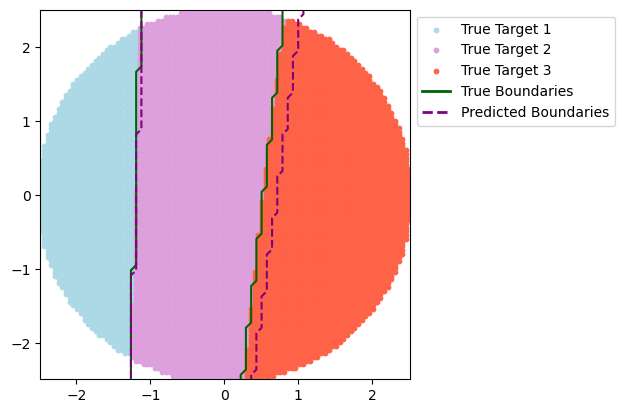

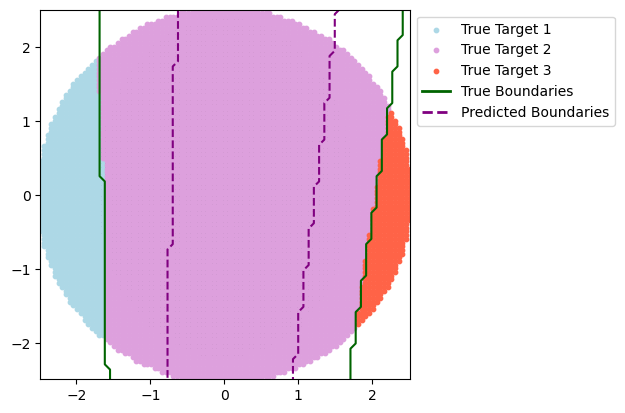

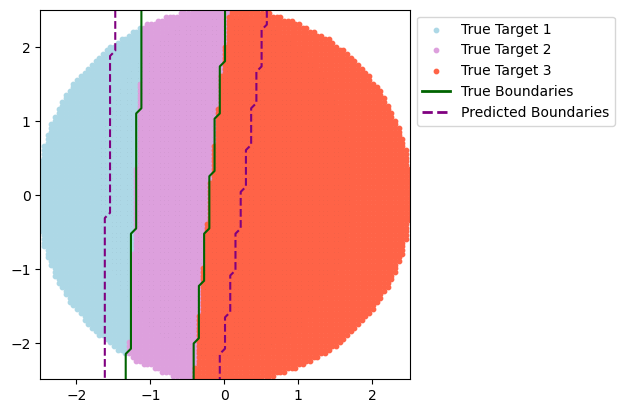

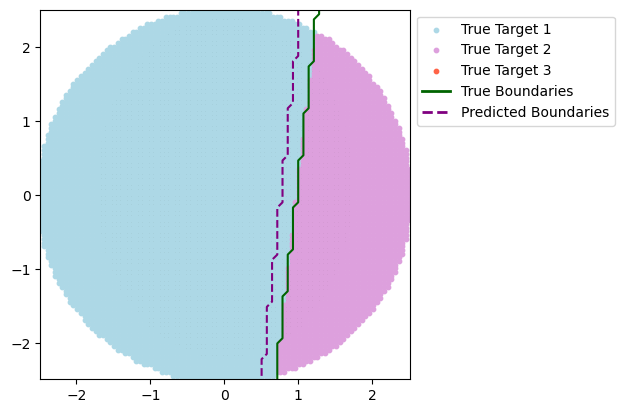

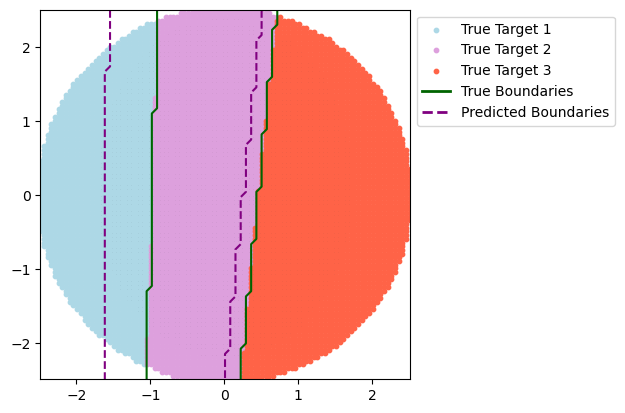

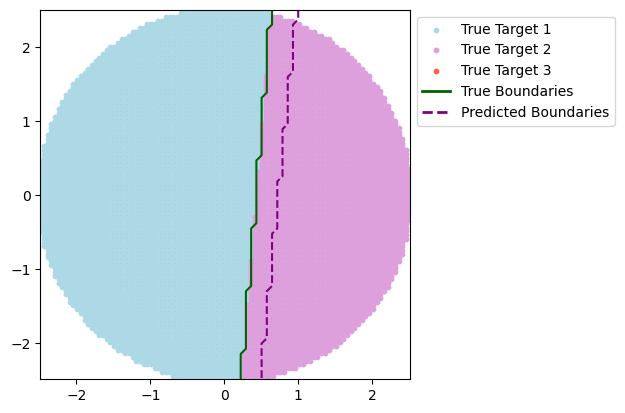

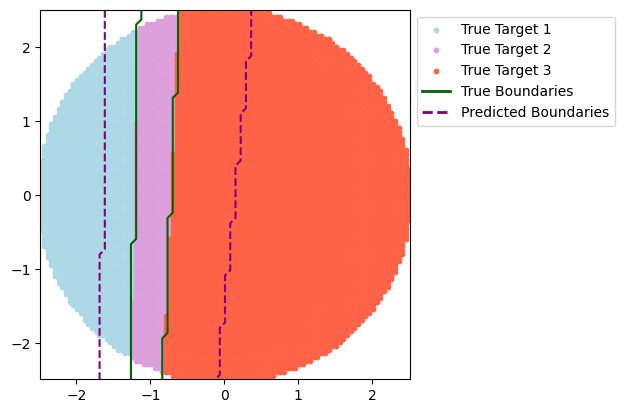

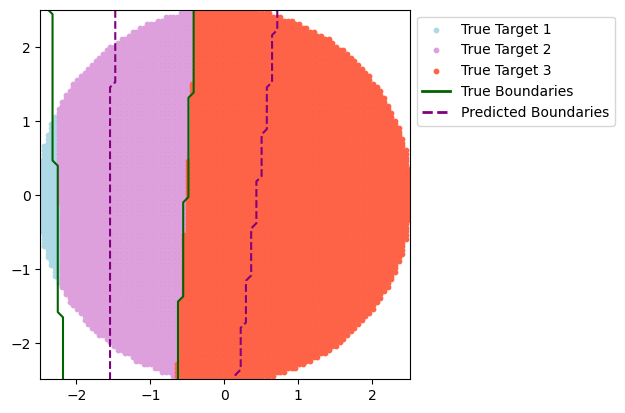

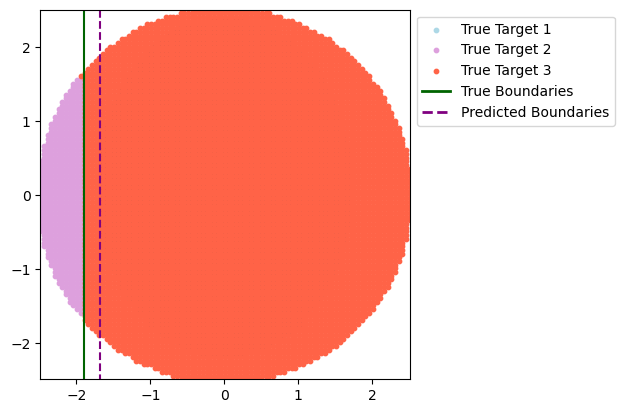

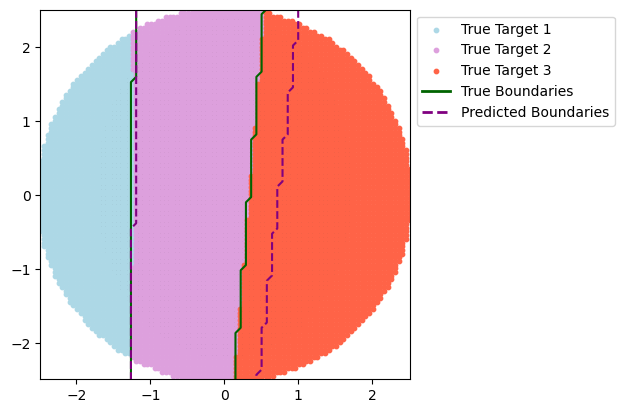

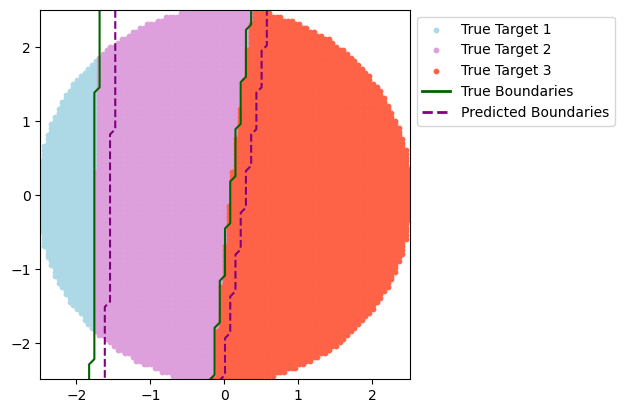

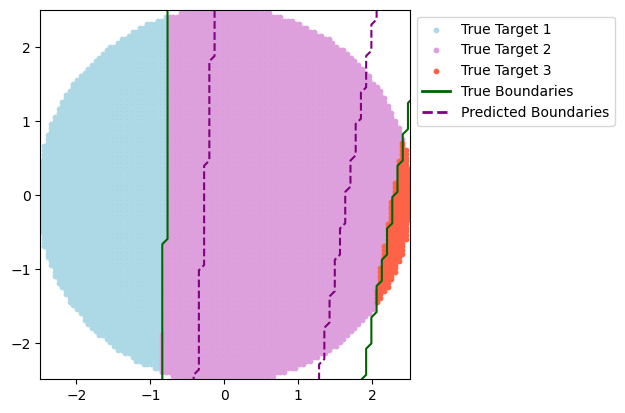

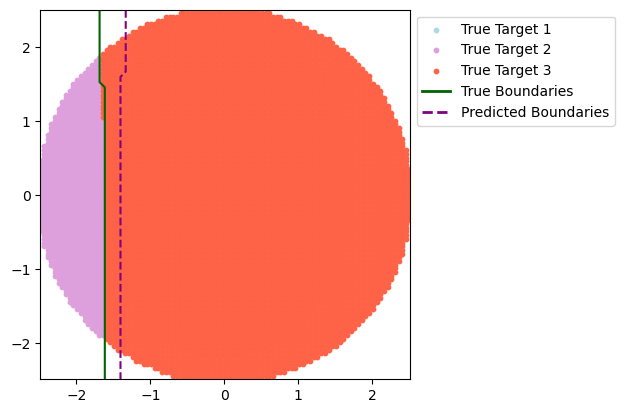

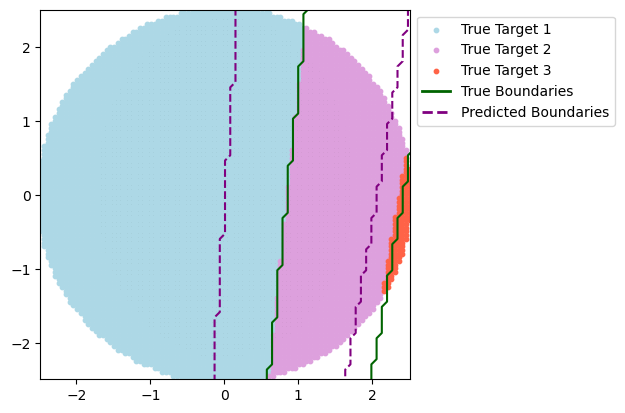

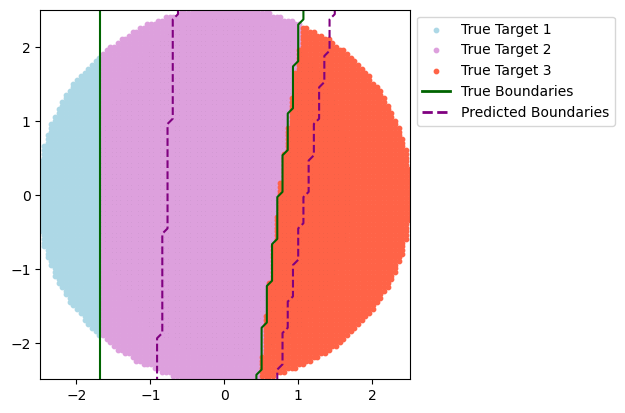

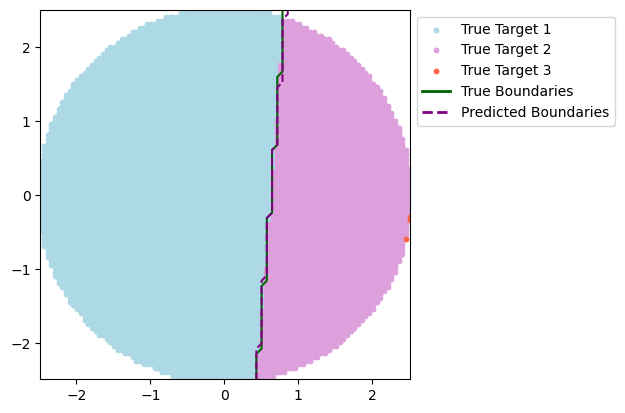

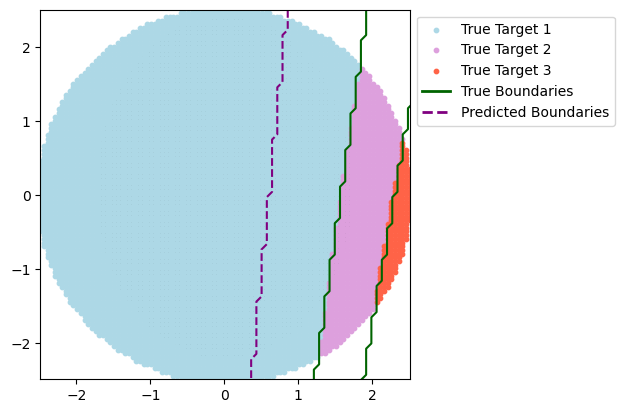

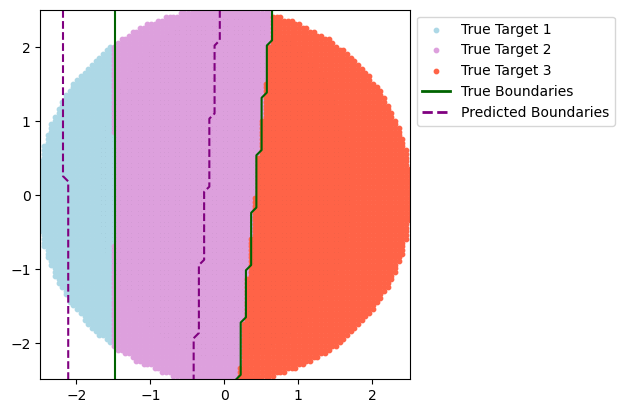

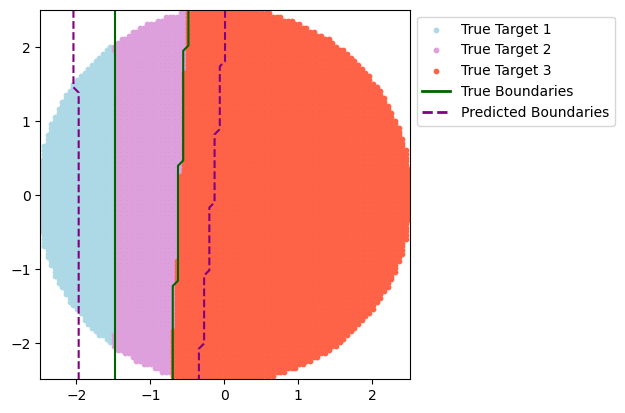

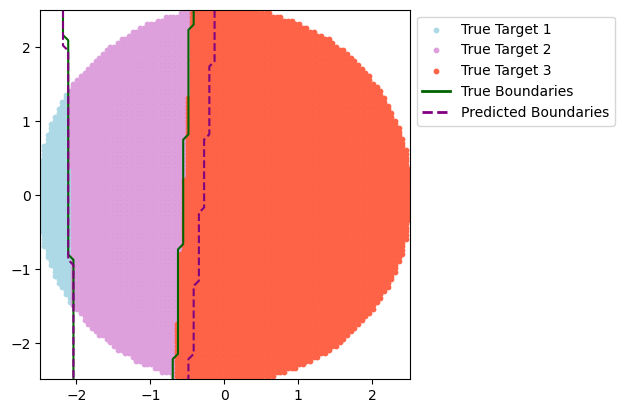

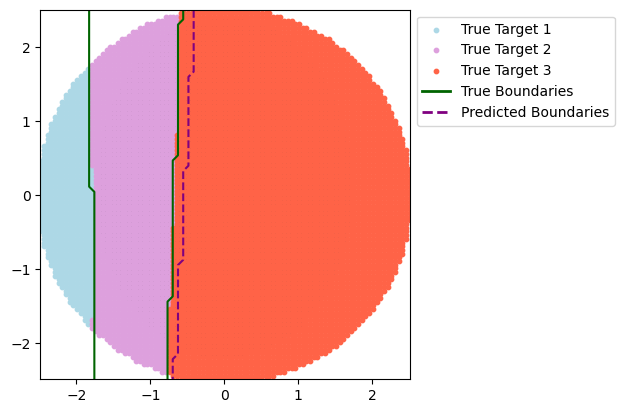

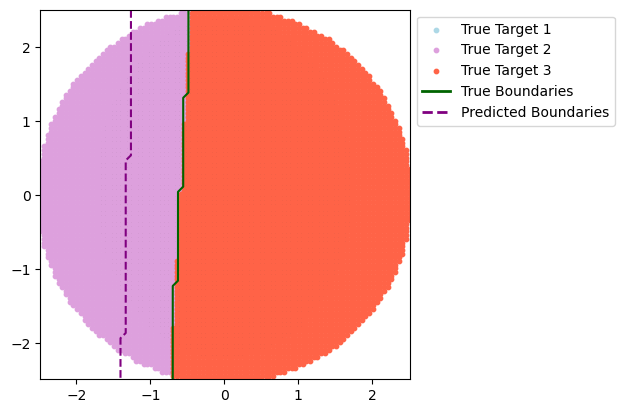

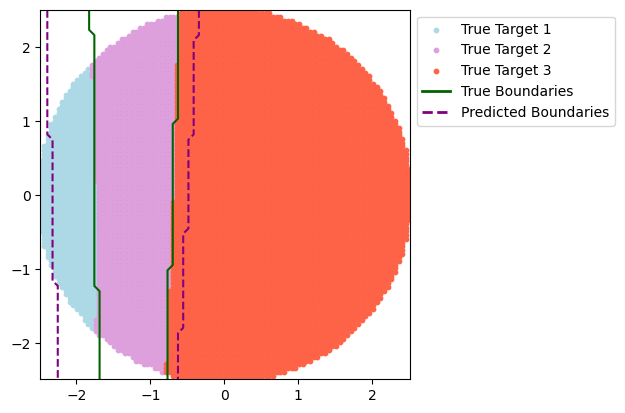

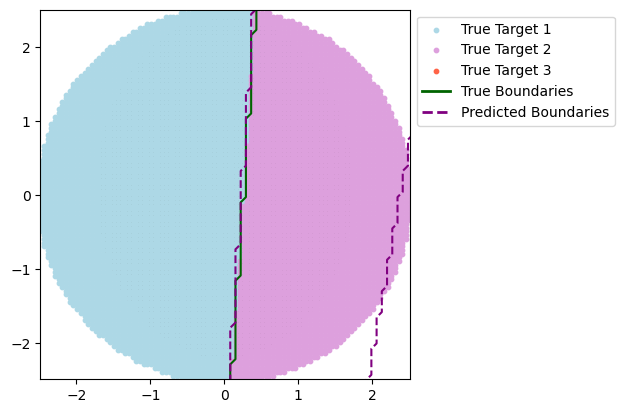

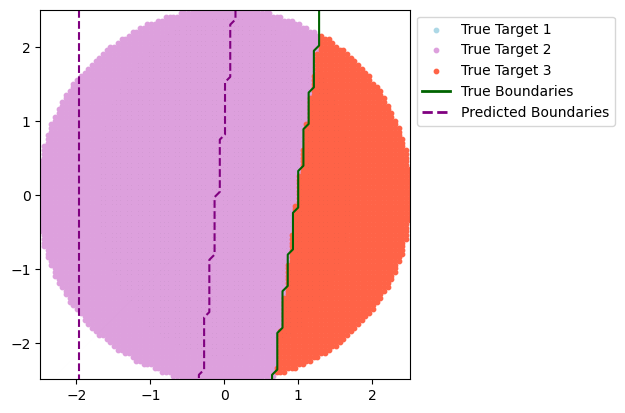

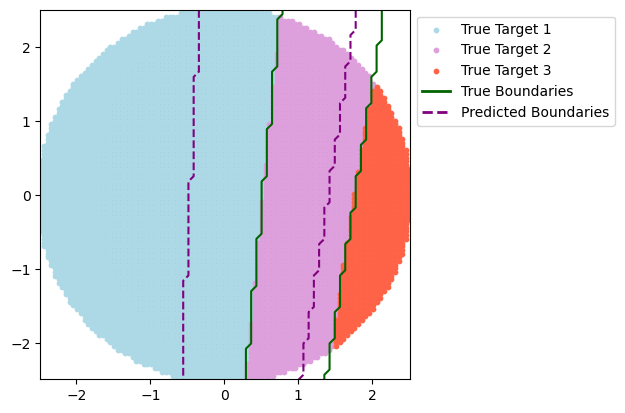

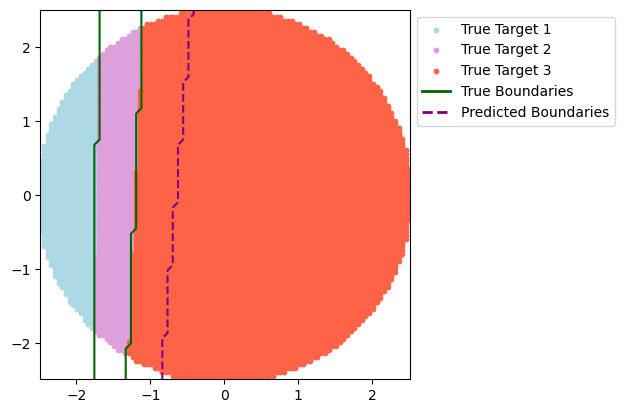

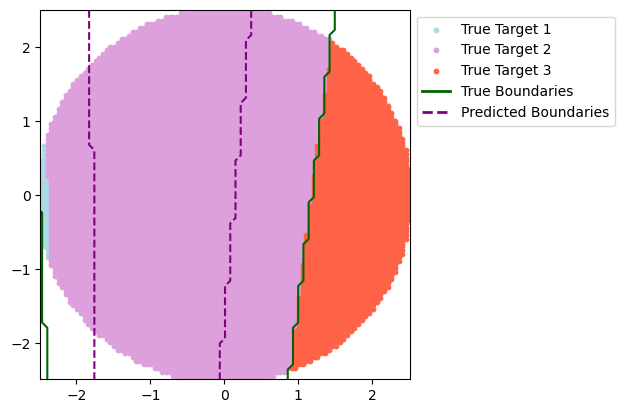

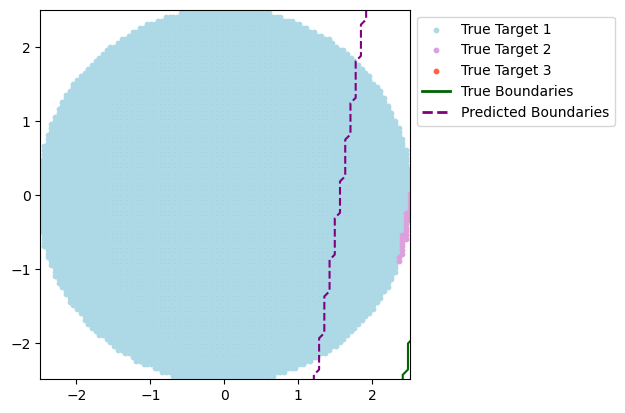

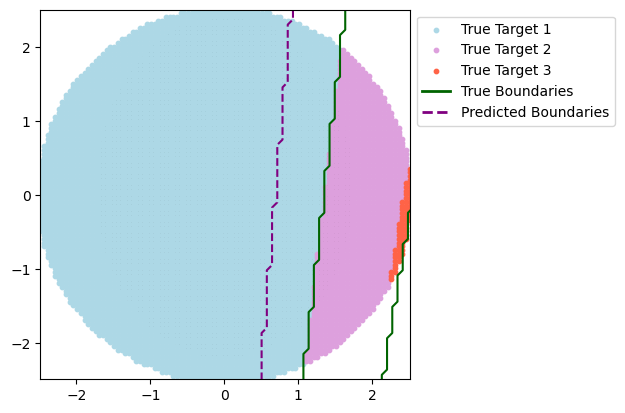

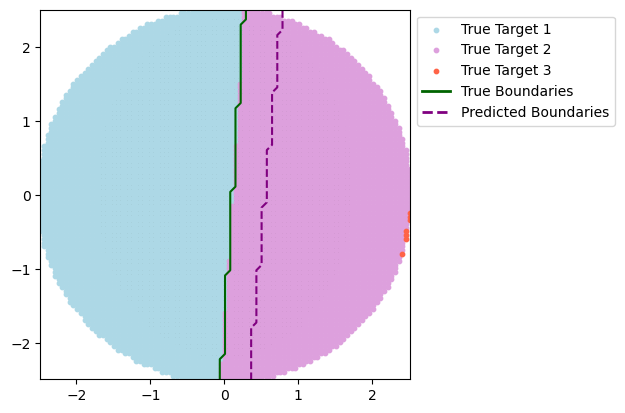

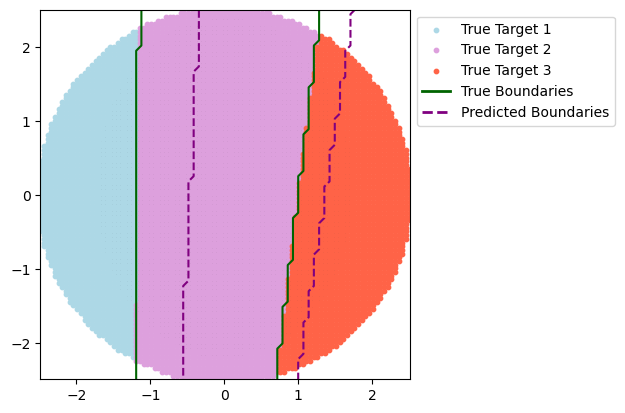

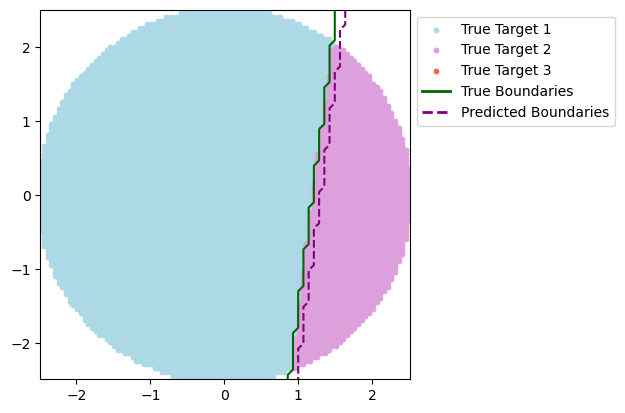

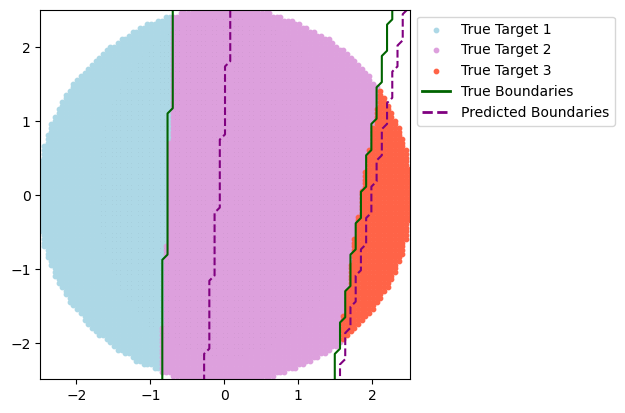

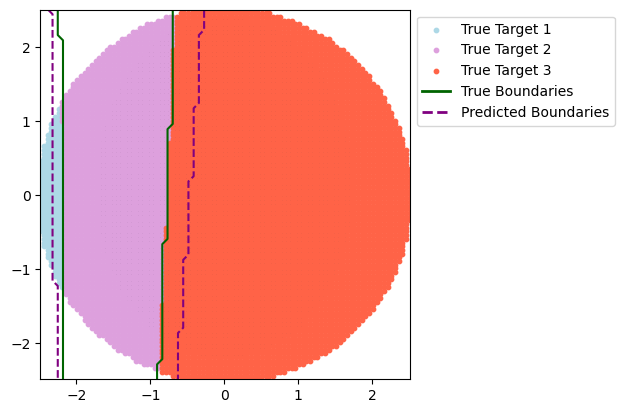

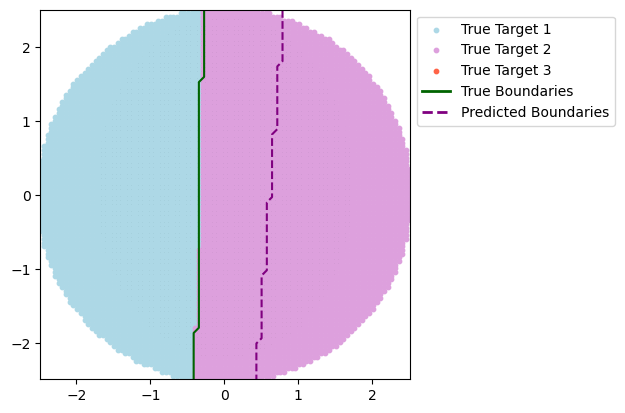

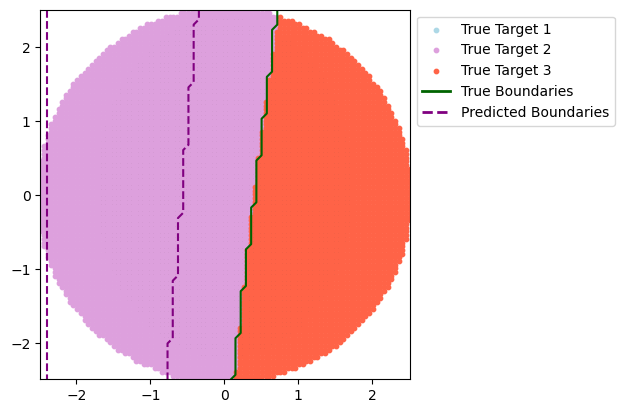

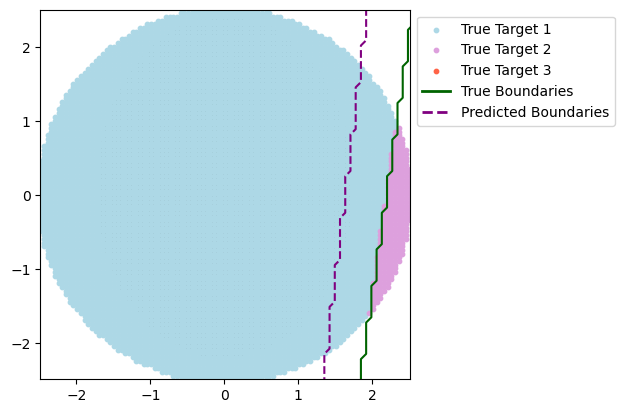

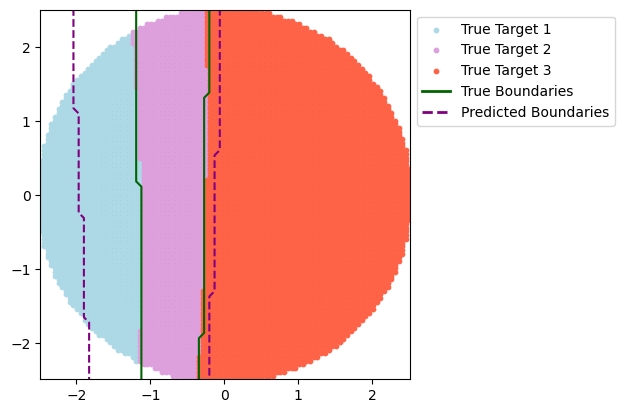

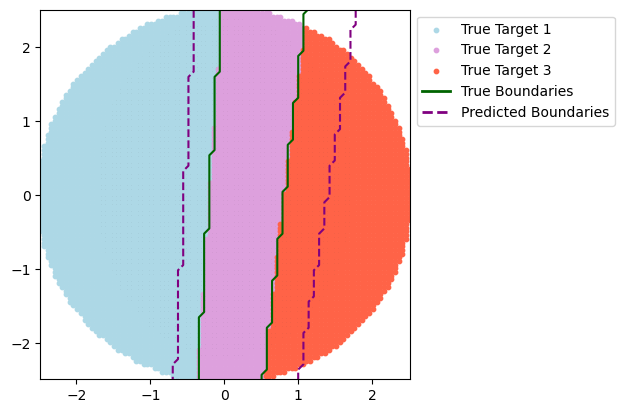

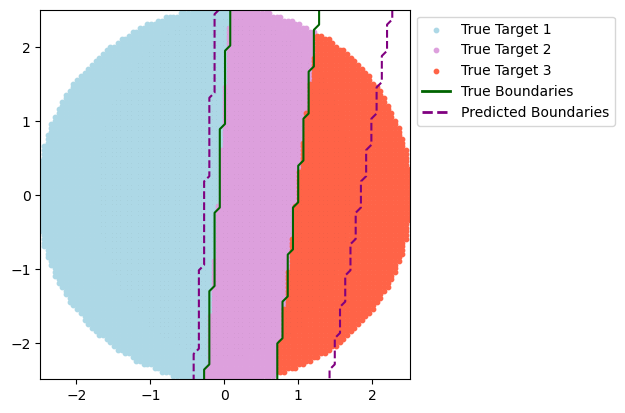

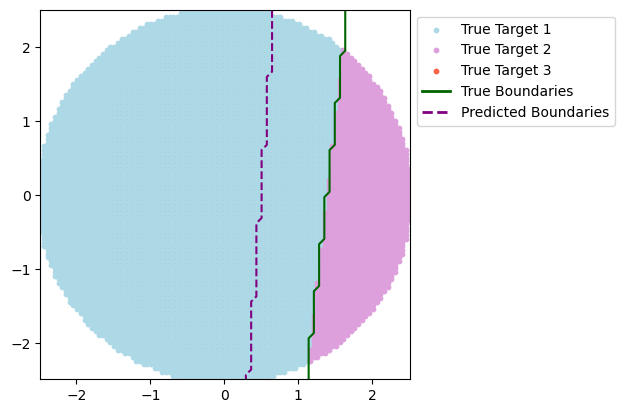

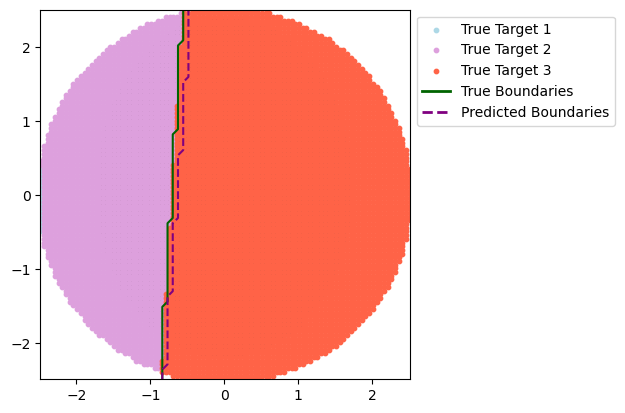

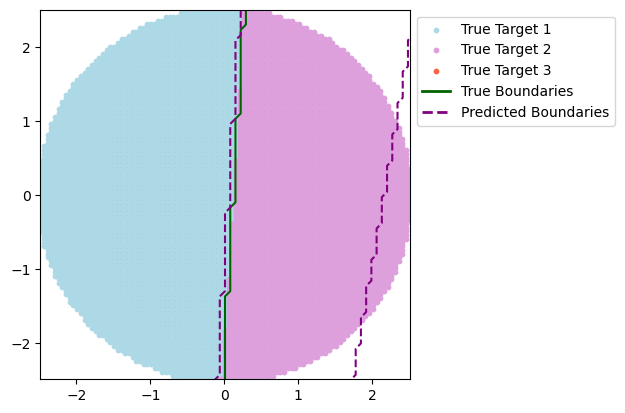

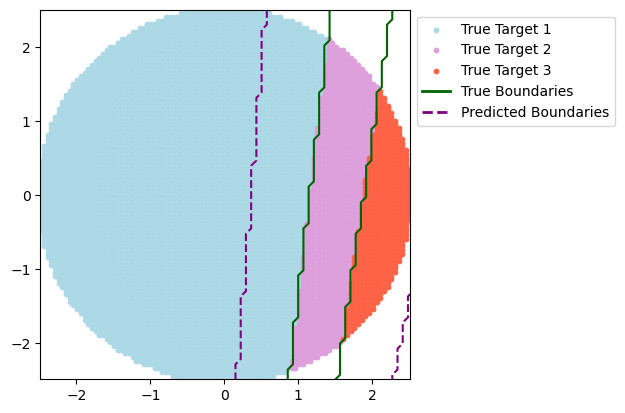

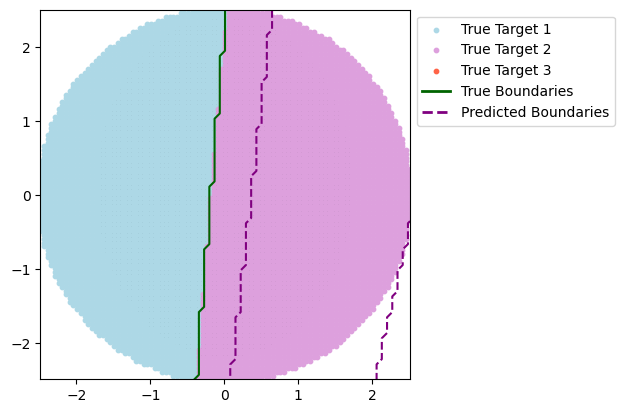

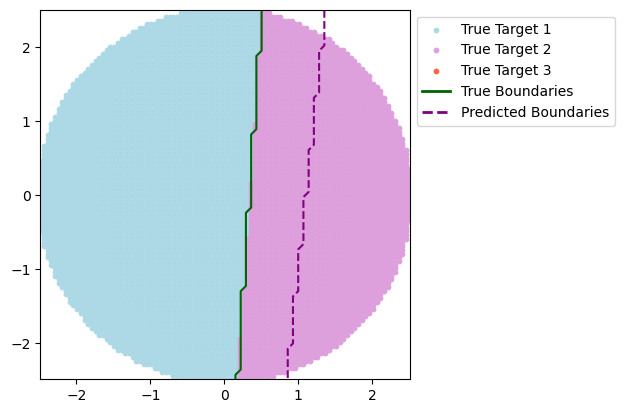

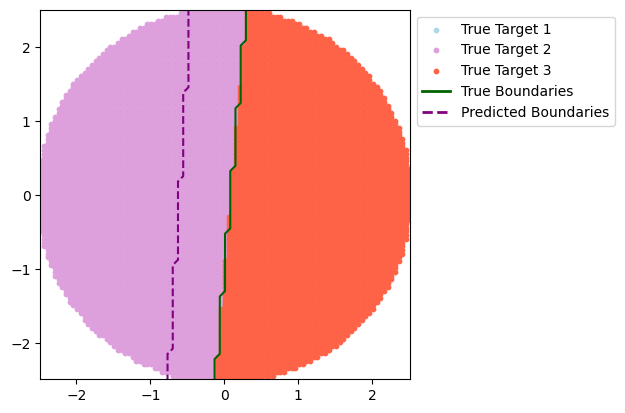

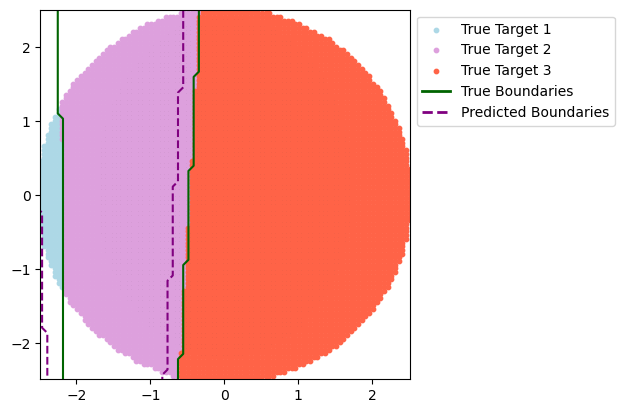

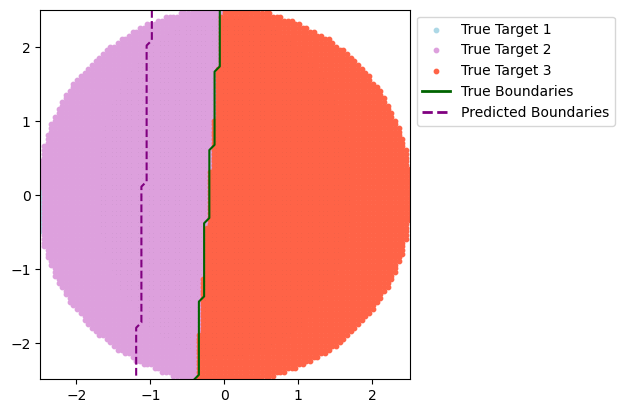

In [17]:
for i in range(50):
    plot_combined_targets_on_image(test_list_pred[i], test_images_list[i]) 